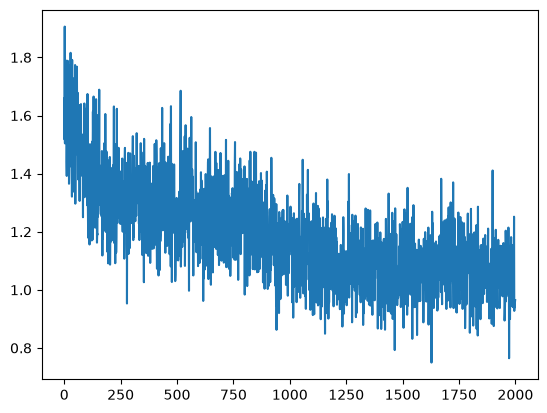

In [1]:
# import libraries
import matplotlib.pyplot as plt
from sckitflow import ModelBuilder
from sckitflow.dataset.toy_data import get_toy_dataset

# create dataset
adata = get_toy_dataset("moons", noise=0.1).adata

# step 1: prepare the data (schema)
builder = ModelBuilder.from_adata(adata)

# step 2: attach the method and get a ready-to-train model
# `device_id` defaults to cuda when available and cpu otherwise, so leaving it
# unset keeps the notebook runnable everywhere.
model = builder.build(
    method_id="cfm",
    vf_decoder_mlp_kwargs={
        "hidden_dims": [
            32,
            32,
        ]
    },
    time_features_id="torch-cfm",
    conditioning_id="resnet1d",
    # probability_path=probability_paths.SchrodingerBridgeProbabilityPath(1.0)
)

# train model
model.train(adata, n_train_steps=2_000, optim_kwargs={"lr": 1e-4})

plt.plot([log["loss"] for log in model.trainer.train_logs_raw])

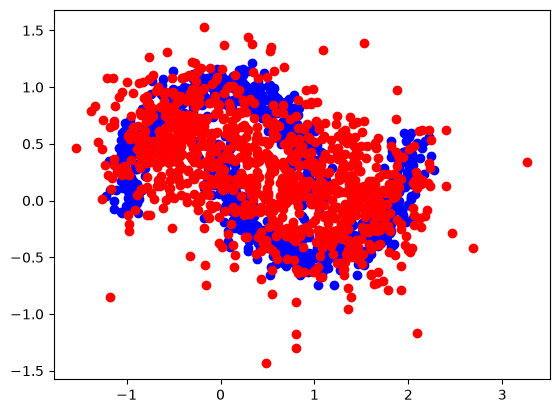

In [2]:
# predict
# CFM here generates from noise (there is no source distribution), so `predict`
# needs to be told how many samples to draw per observation.
adata_pred = model.predict(adata, n_samples=1)

# visualize
plt.scatter(
    adata.X[:, 0],
    adata.X[:, 1],
    color="blue",
)
plt.scatter(adata_pred.X[:, 0], adata_pred.X[:, 1], color="red")